In [36]:
import pandas as pd
import numpy as np
from src.cleaned_data import CleanedData

train_path = r"C:\Users\divye\Data_science_projects\spaceship_titanic\data\train.csv"
test_path = r"C:\Users\divye\Data_science_projects\spaceship_titanic\data\test.csv"

train_data = pd.read_csv(train_path)

train_data = CleanedData.cleaning_df(train_data)

train_data.head()
train_data.isna().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Destination       0
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
Deck              0
Side              0
TotalSpend        0
dtype: int64

In [37]:
test_data = pd.read_csv(test_path)
test_data = CleanedData.cleaning_df(test_data)
test_data.head()
test_data.isna().sum()

PassengerId      0
HomePlanet       0
CryoSleep        0
Destination      0
Age              0
VIP              0
RoomService      0
FoodCourt        0
ShoppingMall     0
Spa              0
VRDeck           0
Name            94
Group            0
Deck             0
Side             0
TotalSpend       0
dtype: int64

In [38]:
print("Missing Names in Train:", train_data['Name'].isna().sum())
print("Missing Names in Test:", test_data['Name'].isna().sum())

# ============================
# 3. Extract LastName (NaN stays NaN)
# ============================
train_data['LastName'] = train_data['Name'].str.split(' ').str[1]
test_data['LastName'] = test_data['Name'].str.split(' ').str[1]

print("\nMissing LastNames in Train:", train_data['LastName'].isna().sum())
print("Missing LastNames in Test:", test_data['LastName'].isna().sum())

train_with_name = train_data[train_data['LastName'].notna()]

family_stats = train_with_name.groupby('LastName').agg(
    FamilySize=('LastName', 'count'),
    FamilySurvivalRate=('Transported', 'mean')
).reset_index()

family_rate_dict = family_stats.set_index('LastName')['FamilySurvivalRate'].to_dict()
family_size_dict = family_stats.set_index('LastName')['FamilySize'].to_dict()

# Map to train and test
train_data['FamilySurvivalRate'] = train_data['LastName'].map(family_rate_dict)
train_data['FamilySize_Name'] = train_data['LastName'].map(family_size_dict)

test_data['FamilySurvivalRate'] = test_data['LastName'].map(family_rate_dict)
test_data['FamilySize_Name'] = test_data['LastName'].map(family_size_dict)


print(train_data[['Name', 'LastName',  'Transported',
                   'FamilySurvivalRate' ]].head(20))

Missing Names in Train: 200
Missing Names in Test: 94

Missing LastNames in Train: 200
Missing LastNames in Test: 94
                  Name     LastName  Transported  FamilySurvivalRate
0      Maham Ofracculy    Ofracculy        False            0.000000
1         Juanna Vines        Vines         True            1.000000
2        Altark Susent       Susent        False            0.500000
3         Solam Susent       Susent        False            0.500000
4    Willy Santantines  Santantines         True            0.500000
5    Sandie Hinetthews   Hinetthews         True            0.571429
6   Billex Jacostaffey  Jacostaffey         True            0.428571
7   Candra Jacostaffey  Jacostaffey         True            0.428571
8        Andona Beston       Beston         True            0.400000
9       Erraiam Flatic       Flatic         True            1.000000
10      Altardr Flatic       Flatic         True            1.000000
11       Wezena Flatic       Flatic         True       

In [39]:
group_stats = train_data.groupby('Group').agg(
    GroupSize_calc=('Group', 'count'),
    GroupSurvivalRate=('Transported', 'mean')
).reset_index()

group_rate_dict = group_stats.set_index('Group')['GroupSurvivalRate'].to_dict()

# Map to train and test
train_data['GroupSurvivalRate'] = train_data['Group'].map(group_rate_dict)
test_data['GroupSurvivalRate'] = test_data['Group'].map(group_rate_dict)

In [40]:
train_data['CombinedSurvivalRate'] = train_data['FamilySurvivalRate'].fillna(
    train_data['GroupSurvivalRate']
)
test_data['CombinedSurvivalRate'] = test_data['FamilySurvivalRate'].fillna(
    test_data['GroupSurvivalRate']
)

# If BOTH are missing (solo traveler with no name), fill with -1
train_data['CombinedSurvivalRate'] = train_data['CombinedSurvivalRate'].fillna(-1)
test_data['CombinedSurvivalRate'] = test_data['CombinedSurvivalRate'].fillna(-1)


# Fill FamilySize_Name missing with 1 (solo)
train_data['FamilySize_Name'] = train_data['FamilySize_Name'].fillna(1)
test_data['FamilySize_Name'] = test_data['FamilySize_Name'].fillna(1)

# ============================
# 8. Create helpful flags
# ============================
# Did we get info from family name?
train_data['Has_Family_Info'] = train_data['FamilySurvivalRate'].notna().astype(int)
test_data['Has_Family_Info'] = test_data['FamilySurvivalRate'].notna().astype(int)

# All family transported?
train_data['Family_All_Transported'] = (train_data['CombinedSurvivalRate'] == 1.0).astype(int)
test_data['Family_All_Transported'] = (test_data['CombinedSurvivalRate'] == 1.0).astype(int)

# No family transported?
train_data['Family_None_Transported'] = (train_data['CombinedSurvivalRate'] == 0.0).astype(int)
test_data['Family_None_Transported'] = (test_data['CombinedSurvivalRate'] == 0.0).astype(int)


drop_cols = ['Name', 'LastName', 'FamilySurvivalRate', 'GroupSurvivalRate']
train_data = train_data.drop(columns=[col for col in drop_cols if col in train_data.columns])
test_data = test_data.drop(columns=[col for col in drop_cols if col in test_data.columns])


In [41]:

test_data.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpend,FamilySize_Name,CombinedSurvivalRate,Has_Family_Info,Family_All_Transported,Family_None_Transported
count,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000,4277.00000,4277.000000,4277.000000,4277.000000,4277.000000,4277.000000
mean,29.090250,215.062427,428.592238,173.233107,295.895955,304.898293,1417.68202,3.695113,0.310033,0.878887,0.143325,0.138181
std,13.475432,601.914503,1510.155974,554.991776,1104.872018,1235.991811,2816.40210,2.550905,0.569759,0.326297,0.350445,0.345130
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,-1.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,1.000000,0.000000,0.000000
50%,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,714.00000,3.000000,0.428571,1.000000,0.000000,0.000000
75%,37.000000,48.000000,66.000000,27.000000,43.000000,31.000000,1444.00000,5.000000,0.666667,1.000000,0.000000,0.000000
max,79.000000,11567.000000,25273.000000,8292.000000,19844.000000,22272.000000,33666.00000,15.000000,1.000000,1.000000,1.000000,1.000000


In [42]:
train_data.describe()


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpend,FamilySize_Name,CombinedSurvivalRate,Has_Family_Info,Family_All_Transported,Family_None_Transported
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,29.296330,220.009318,448.434027,169.572300,304.588865,298.261820,1440.866329,5.326240,0.503316,0.976993,0.106753,0.096399
std,13.759148,660.519050,1595.790627,598.007164,1125.562559,1134.126417,2803.045694,2.934528,0.277924,0.149934,0.308816,0.295155
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.333333,1.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,716.000000,5.000000,0.500000,1.000000,0.000000,0.000000
75%,37.000000,41.000000,61.000000,22.000000,53.000000,40.000000,1441.000000,7.000000,0.666667,1.000000,0.000000,0.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000,35987.000000,18.000000,1.000000,1.000000,1.000000,1.000000


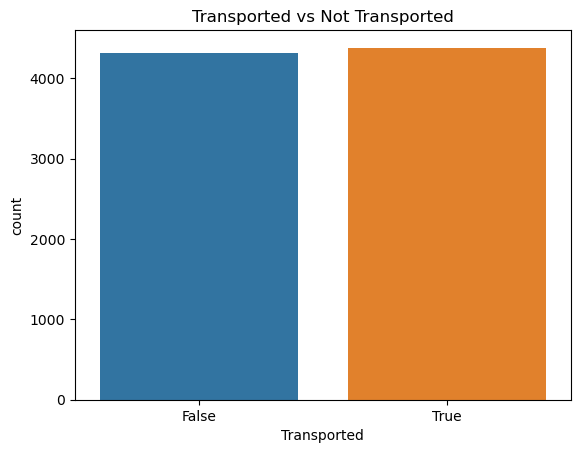

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=train_data, x='Transported')
plt.title("Transported vs Not Transported")
plt.show()

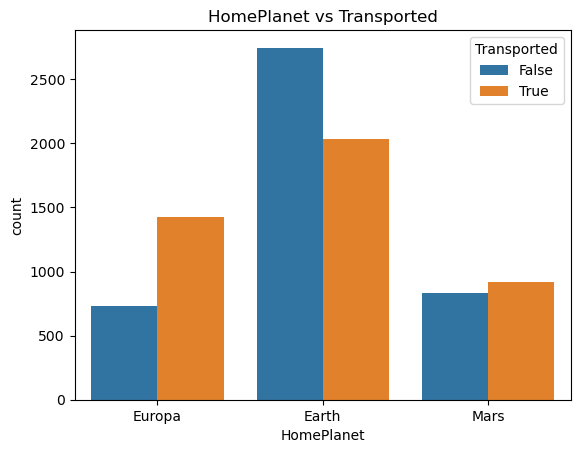

In [44]:
sns.countplot(data=train_data, x='HomePlanet', hue='Transported')
plt.title("HomePlanet vs Transported")
plt.show()

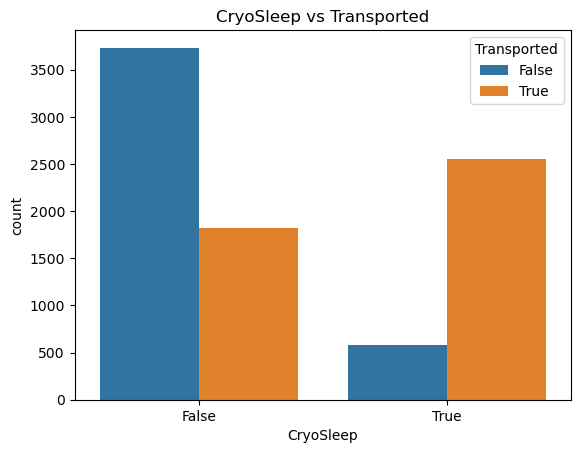

In [45]:
sns.countplot(data=train_data, x='CryoSleep', hue='Transported')
plt.title("CryoSleep vs Transported")
plt.show()

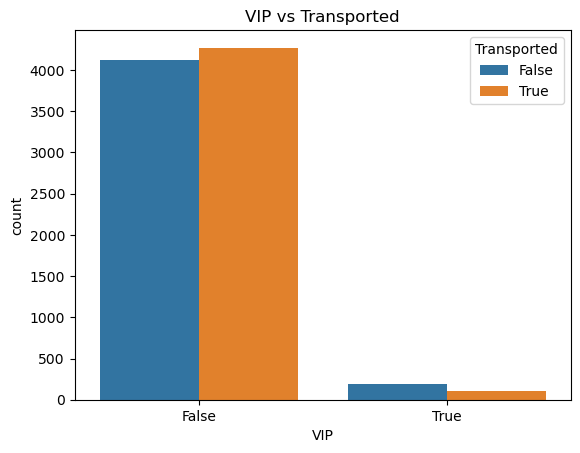

In [46]:
sns.countplot(data=train_data, x='VIP', hue='Transported')
plt.title("VIP vs Transported")
plt.show()

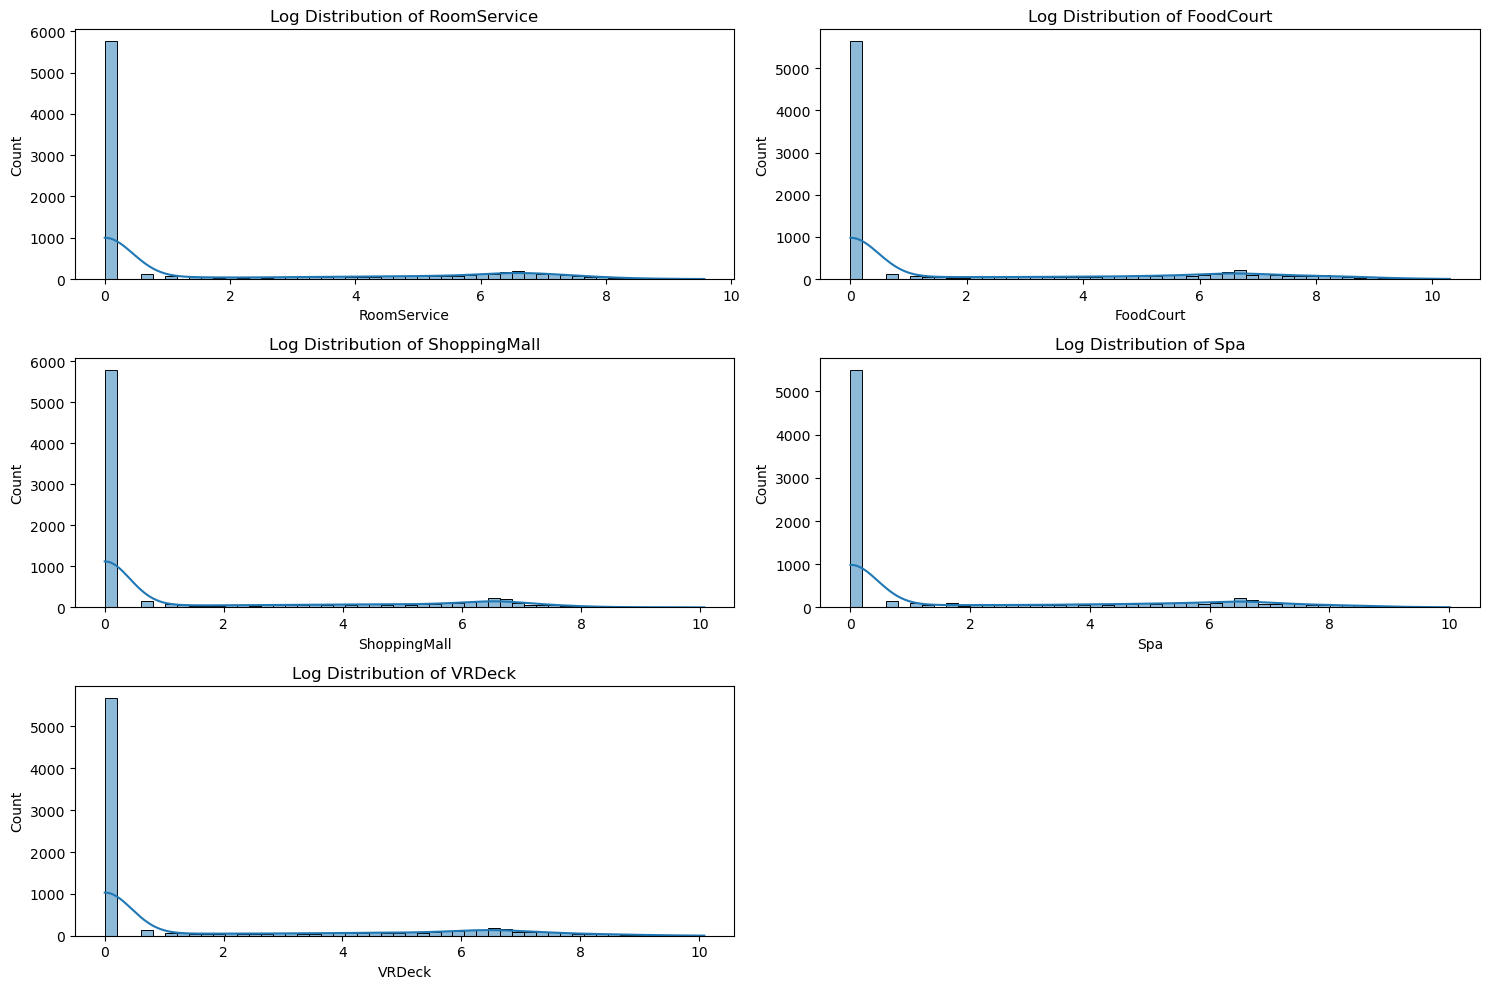

In [47]:

spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
plt.figure(figsize=(15,10))

for i, col in enumerate(spend_cols):
    plt.subplot(3, 2, i+1)
    sns.histplot(np.log1p(train_data[col]), bins=50, kde=True)
    plt.title(f"Log Distribution of {col}")

plt.tight_layout()
plt.show()

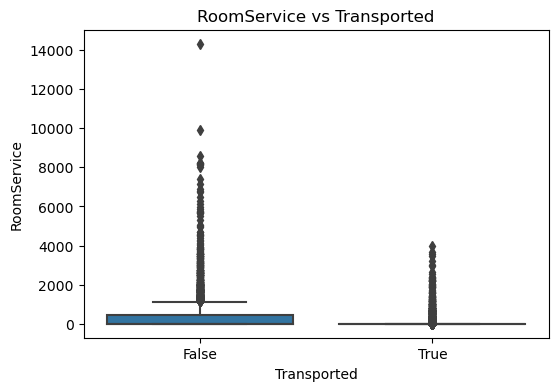

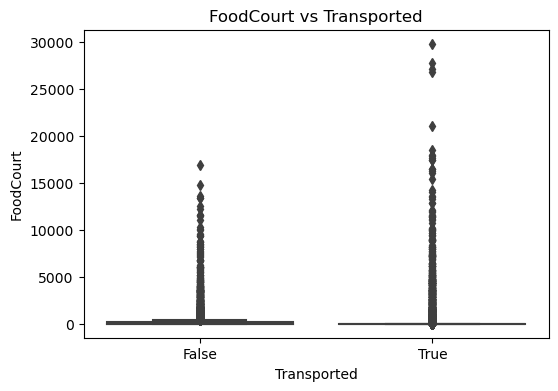

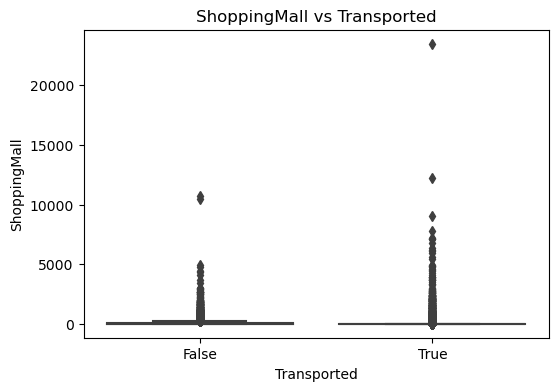

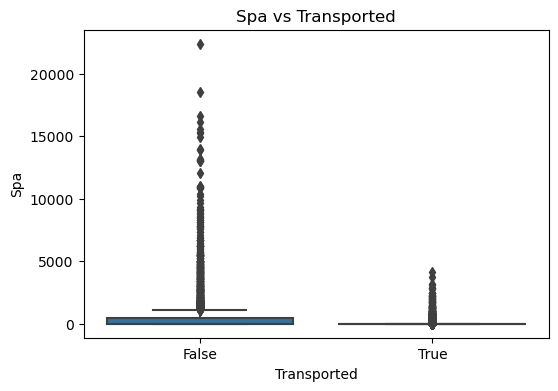

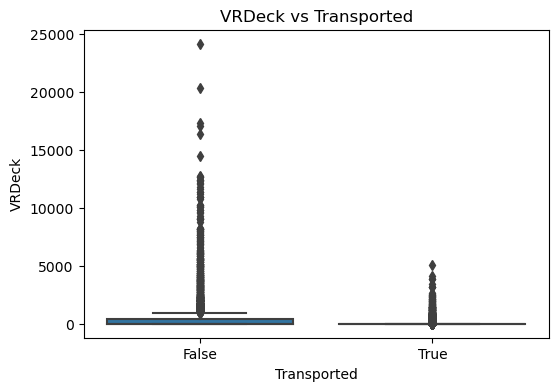

In [48]:
for col in spend_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=train_data, x='Transported', y=col)
    plt.title(f"{col} vs Transported")
    plt.show()

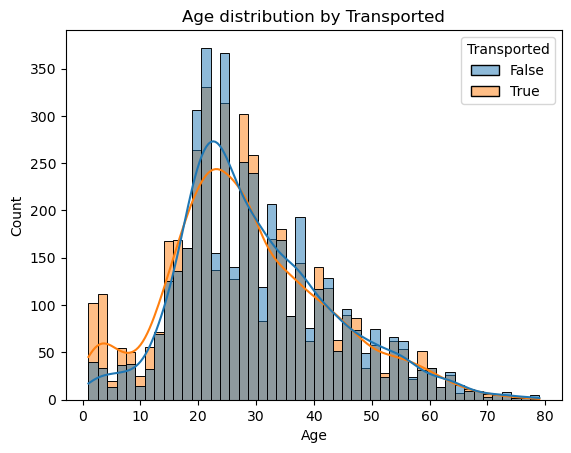

In [49]:
sns.histplot(data=train_data, x='Age', hue='Transported', kde=True)
plt.title("Age distribution by Transported")
plt.show()

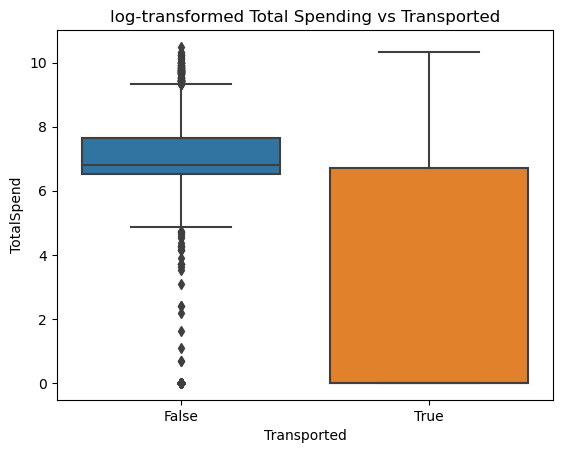

In [50]:


sns.boxplot(data=train_data, x='Transported', y=np.log1p(train_data['TotalSpend']))
plt.title("log-transformed Total Spending vs Transported")
plt.show()

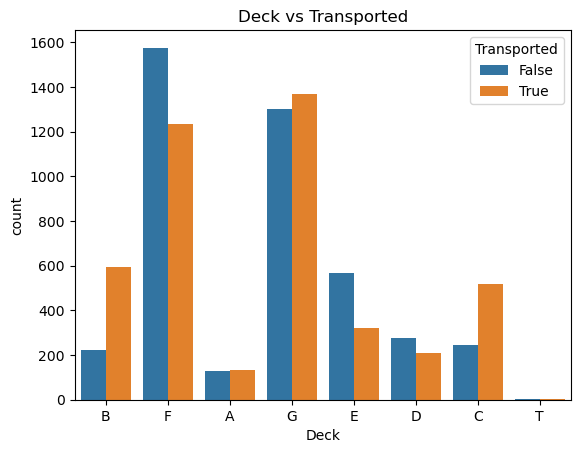

In [51]:
sns.countplot(data=train_data, x='Deck', hue='Transported')
plt.title("Deck vs Transported")
plt.show()

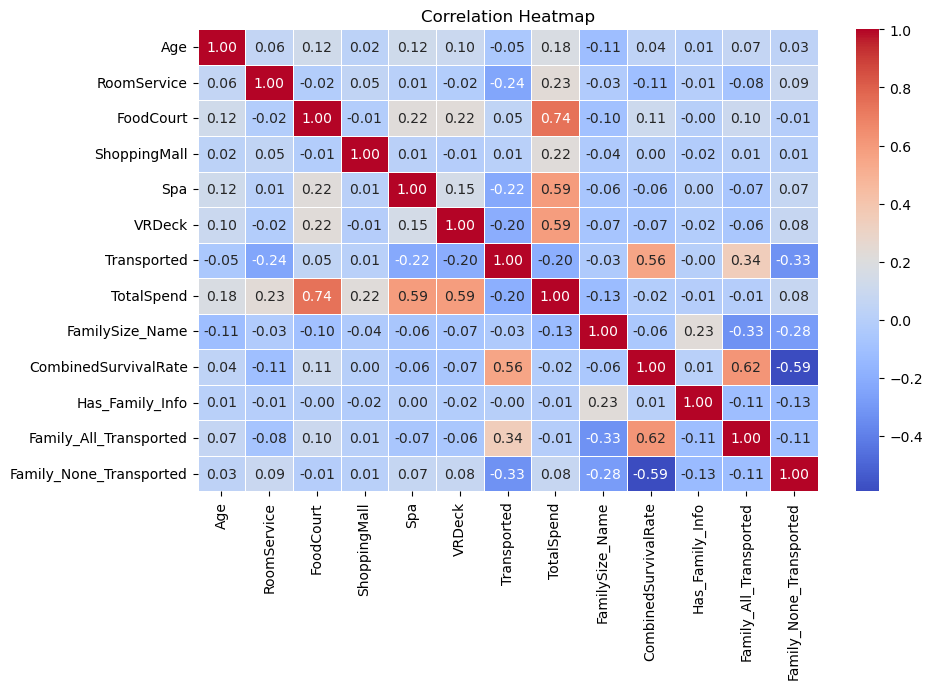

In [52]:
plt.figure(figsize=(10,6))
sns.heatmap(train_data.corr(numeric_only=True), 
            annot=True, 
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [53]:
train_data.groupby('Transported')['TotalSpend'].mean()

Transported
False    2004.149247
True      885.689127
Name: TotalSpend, dtype: float64

In [54]:
train_data['Cryo_NoSpend'] = (
    (train_data['CryoSleep'] == True) & (train_data['TotalSpend'] == 0)
).astype(int)
test_data['Cryo_NoSpend'] = (
    (test_data['CryoSleep'] == True) & (test_data['TotalSpend'] == 0)
).astype(int)

In [55]:
def age_group(x):
    if x < 13:
        return 'Child'
    elif x < 20:
        return 'Teen'
    elif x < 35:
        return 'YoungAdult'
    elif x < 60:
        return 'Adult'
    else:
        return 'Senior'

train_data['AgeGroup'] = train_data['Age'].apply(age_group)
test_data['AgeGroup'] = test_data['Age'].apply(age_group)

In [56]:
group_size = train_data.groupby('Group')['PassengerId'].transform('count')
train_data['GroupSize'] = group_size

group_size_test = test_data.groupby('Group')['PassengerId'].transform('count')
test_data['GroupSize'] = group_size_test

In [57]:
train_data['IsAlone'] = (train_data['GroupSize'] == 1).astype(int)
test_data['IsAlone'] = (test_data['GroupSize'] == 1).astype(int)

In [58]:
train_data['Cryo_RoomService'] = (
    train_data['CryoSleep'].astype(int) * train_data['RoomService']
)

test_data['Cryo_RoomService'] = (
    test_data['CryoSleep'].astype(int) * test_data['RoomService']
)

In [59]:
train_data['CryoSpend'] = train_data['CryoSleep'].astype(int) * train_data['TotalSpend']
test_data['CryoSpend'] = test_data['CryoSleep'].astype(int) * test_data['TotalSpend']

In [60]:
threshold = train_data['TotalSpend'].quantile(0.75)

train_data['HighSpender'] = (train_data['TotalSpend'] > threshold).astype(int)
test_data['HighSpender'] = (test_data['TotalSpend'] > threshold).astype(int)

In [61]:
train_data['SpendPerPerson'] = train_data['TotalSpend'] / train_data['GroupSize']
test_data['SpendPerPerson'] = test_data['TotalSpend'] / test_data['GroupSize']

In [62]:
train_data['DeckSide'] = train_data['Deck'] + "_" + train_data['Side']
test_data['DeckSide'] = test_data['Deck'] + "_" + test_data['Side']

In [63]:
train_data['NoRoomService'] = (train_data['RoomService'] == 0).astype(int)
test_data['NoRoomService'] = (test_data['RoomService'] == 0).astype(int)

In [64]:
train_data['LuxurySpend'] = train_data['Spa'] + train_data['VRDeck']
test_data['LuxurySpend'] = test_data['Spa'] + test_data['VRDeck']

In [65]:
train_data['Cryo_Luxury'] = train_data['CryoSleep'].astype(int) * (train_data['LuxurySpend'] > 0).astype(int)
test_data['Cryo_Luxury'] = test_data['CryoSleep'].astype(int) * (test_data['LuxurySpend'] > 0).astype(int)

In [66]:
amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

train_data['Amenities_Used'] = (train_data[amenities] > 0).sum(axis=1)
test_data['Amenities_Used'] = (test_data[amenities] > 0).sum(axis=1)

In [67]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   PassengerId              8693 non-null   object 
 1   HomePlanet               8693 non-null   object 
 2   CryoSleep                8693 non-null   object 
 3   Destination              8693 non-null   object 
 4   Age                      8693 non-null   float64
 5   VIP                      8693 non-null   object 
 6   RoomService              8693 non-null   float64
 7   FoodCourt                8693 non-null   float64
 8   ShoppingMall             8693 non-null   float64
 9   Spa                      8693 non-null   float64
 10  VRDeck                   8693 non-null   float64
 11  Transported              8693 non-null   bool   
 12  Group                    8693 non-null   object 
 13  Deck                     8693 non-null   object 
 14  Side                    

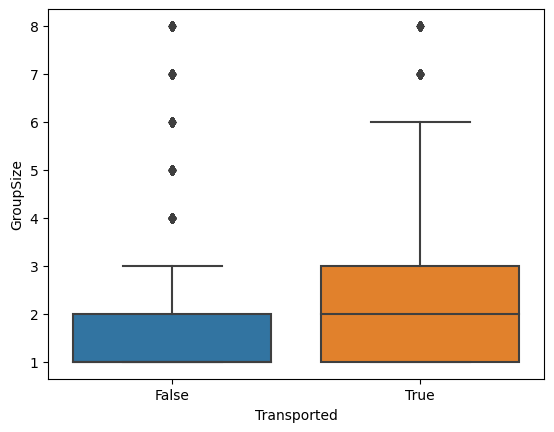

In [68]:
sns.boxplot(data=train_data, x='Transported', y='GroupSize')
plt.show()

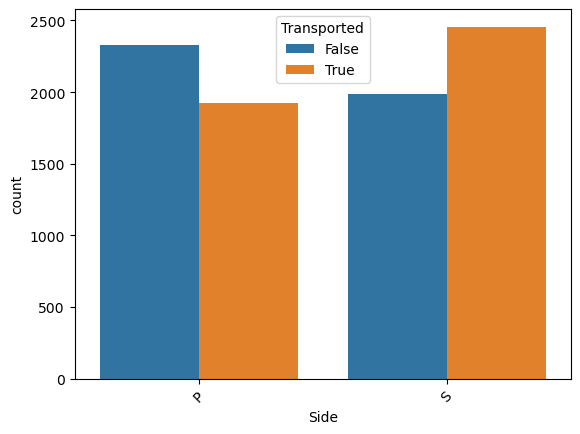

In [69]:
sns.countplot(data=train_data, x='Side', hue='Transported')
plt.xticks(rotation=45)
plt.show()

In [70]:


train_data.to_csv(r"C:\Users\divye\Data_science_projects\spaceship_titanic\data\cleaned_train.csv",index=False)
test_data.to_csv(r"C:\Users\divye\Data_science_projects\spaceship_titanic\data\cleaned_test.csv",index=False)